In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense, Softmax
from tensorflow.keras import optimizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
data = pd.read_csv("heart.csv",sep=";")
x = data[['Age','RestingBP','Cholesterol','FastingBS','MaxHR','Oldpeak']]
y = data[['HeartDisease']]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=123)

In [3]:
x_train

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak
660,58,140,211,1,165,0.0
426,56,126,166,0,140,0.0
338,63,140,0,1,149,2.0
151,48,100,159,0,100,0.0
542,54,138,274,0,105,1.5
...,...,...,...,...,...,...
98,56,120,85,0,140,0.0
322,38,105,0,1,166,2.8
382,43,115,0,0,145,2.0
365,64,200,0,0,140,1.0


In [4]:
y

,HeartDisease
0,0
1,1
2,0
3,1
4,0
...,...
913,1
914,1
915,1
916,1


In [5]:
# build a model
model = Sequential()
model.add(Dense(4, input_shape=(x_train.shape[1],), activation='relu')) # Add an input shape! (features,)
model.add(Dense(4, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary() 

# compile the model
model.compile(optimizer='Adam', 
              loss='binary_crossentropy',
              metrics=['accuracy'])

# now we just update our model fit call
history = model.fit(x_train, y_train,
                    epochs=150, # you can set this to a big number!
                    batch_size=20,
                    validation_data = (x_test, y_test),
                    verbose=1)

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 4)                 28        
_________________________________________________________________
dense_1 (Dense)              (None, 4)                 20        
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 5         
Total params: 53
Trainable params: 53
Non-trainable params: 0
_________________________________________________________________
Epoch 1/150
37/37 [==============================] - 2s 37ms/step - loss: 5.6240 - accuracy: 0.5165 - val_loss: 3.4555 - val_accuracy: 0.5326
Epoch 2/150
37/37 [==============================] - 0s 2ms/step - loss: 2.5311 - accuracy: 0.5801 - val_loss: 1.2804 - val_accuracy: 0.6250
Epoch 3/150
37/37 [==============================] - 0s 3ms/step - loss: 1.0986 - accuracy: 0.6216 - val_lo

37/37 [==============================] - 0s 2ms/step - loss: 0.5550 - accuracy: 0.7333 - val_loss: 0.5917 - val_accuracy: 0.7065
Epoch 54/150
37/37 [==============================] - 0s 2ms/step - loss: 0.5450 - accuracy: 0.7491 - val_loss: 0.5915 - val_accuracy: 0.6848
Epoch 55/150
37/37 [==============================] - 0s 2ms/step - loss: 0.5766 - accuracy: 0.7203 - val_loss: 0.5870 - val_accuracy: 0.7174
Epoch 56/150
37/37 [==============================] - 0s 2ms/step - loss: 0.5397 - accuracy: 0.7421 - val_loss: 0.5848 - val_accuracy: 0.7228
Epoch 57/150
37/37 [==============================] - 0s 2ms/step - loss: 0.5501 - accuracy: 0.7337 - val_loss: 0.5823 - val_accuracy: 0.7228
Epoch 58/150
37/37 [==============================] - 0s 2ms/step - loss: 0.5426 - accuracy: 0.7433 - val_loss: 0.5802 - val_accuracy: 0.7283
Epoch 59/150
37/37 [==============================] - 0s 2ms/step - loss: 0.5609 - accuracy: 0.7207 - val_loss: 0.5867 - val_accuracy: 0.7174
Epoch 60/150
37/37 

Epoch 111/150
37/37 [==============================] - 0s 2ms/step - loss: 0.4962 - accuracy: 0.7731 - val_loss: 0.5375 - val_accuracy: 0.7446
Epoch 112/150
37/37 [==============================] - 0s 2ms/step - loss: 0.4960 - accuracy: 0.7811 - val_loss: 0.5523 - val_accuracy: 0.7228
Epoch 113/150
37/37 [==============================] - 0s 2ms/step - loss: 0.5384 - accuracy: 0.7346 - val_loss: 0.5443 - val_accuracy: 0.7174
Epoch 114/150
37/37 [==============================] - 0s 2ms/step - loss: 0.5069 - accuracy: 0.7787 - val_loss: 0.5370 - val_accuracy: 0.7391
Epoch 115/150
37/37 [==============================] - 0s 2ms/step - loss: 0.5097 - accuracy: 0.7496 - val_loss: 0.5610 - val_accuracy: 0.7283
Epoch 116/150
37/37 [==============================] - 0s 2ms/step - loss: 0.4945 - accuracy: 0.7745 - val_loss: 0.5391 - val_accuracy: 0.7337
Epoch 117/150
37/37 [==============================] - 0s 2ms/step - loss: 0.5142 - accuracy: 0.7595 - val_loss: 0.5373 - val_accuracy: 0.7500

In [6]:
score = model.evaluate(x_test, y_test, verbose=0)

print('Test loss     :', score[0])
print('Test accuracy :', score[1])

Test loss     : 0.5265962481498718
Test accuracy : 0.739130437374115


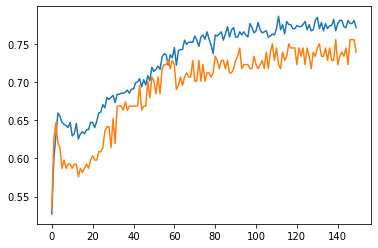

In [7]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

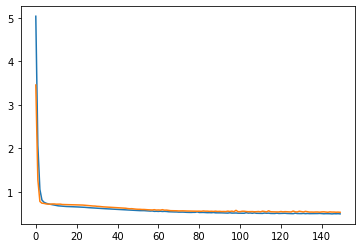

In [9]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [12]:
model.predict(x_test) # prob of Heart Disease
preds = np.round(model.predict(x_test),0) # 1 and 0 (survival or not)
y_test # 1 and 0 (Heart Disease or not)
print(confusion_matrix(y_test, preds)) # order matters! (actual, predicted)

[[53 28]
 [20 83]]


In [13]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.73      0.65      0.69        81
           1       0.75      0.81      0.78       103

    accuracy                           0.74       184
   macro avg       0.74      0.73      0.73       184
weighted avg       0.74      0.74      0.74       184



In [14]:
# Precision
83/(28+83)

0.7477477477477478

In [15]:
# Accuracy
(83+53)/(53+28+83+20)

0.7391304347826086